In [1]:
import pandas as pd

# Load Dataset
df = pd.read_csv("data/dataset.csv")

# Show first 5 rows
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [3]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [4]:
print("Rows and Columns:", df.shape)

Rows and Columns: (1470, 35)


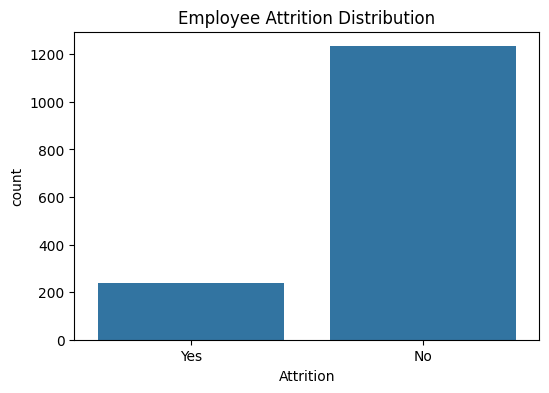

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x="Attrition", data=df)

plt.title("Employee Attrition Distribution")
plt.savefig("images/attrition_distribution.png")

plt.show()

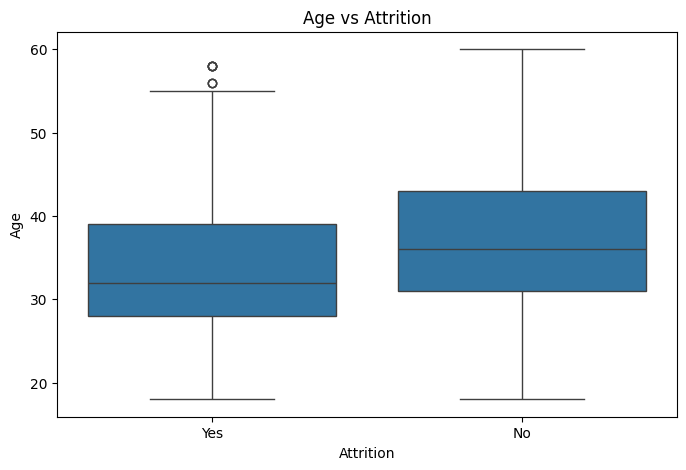

In [6]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Attrition", y="Age", data=df)

plt.title("Age vs Attrition")
plt.savefig("images/age_vs_attrition.png")

plt.show()

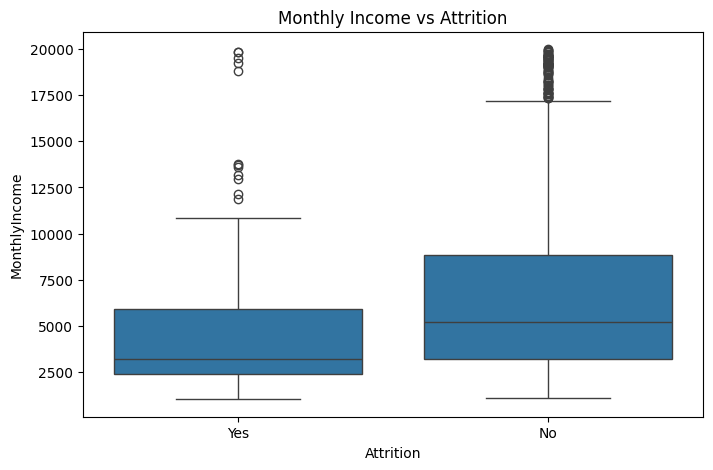

In [7]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Attrition", y="MonthlyIncome", data=df)

plt.title("Monthly Income vs Attrition")
plt.savefig("images/income_vs_attrition.png")

plt.show()

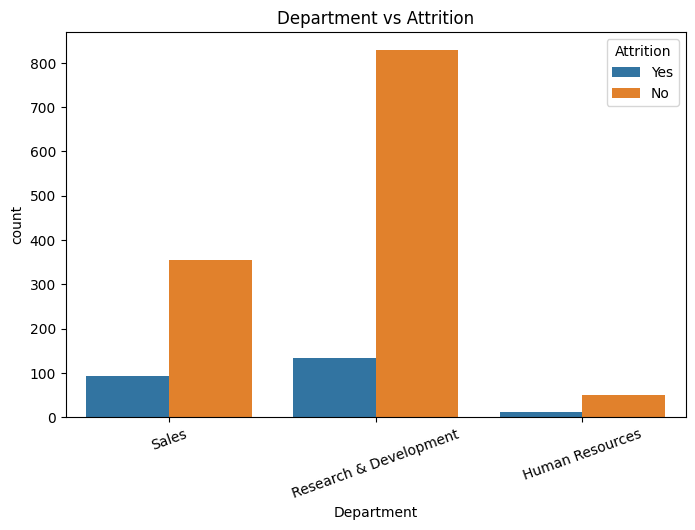

In [8]:
plt.figure(figsize=(8,5))
sns.countplot(x="Department", hue="Attrition", data=df)

plt.xticks(rotation=20)
plt.title("Department vs Attrition")
plt.savefig("images/department_vs_attrition.png")

plt.show()

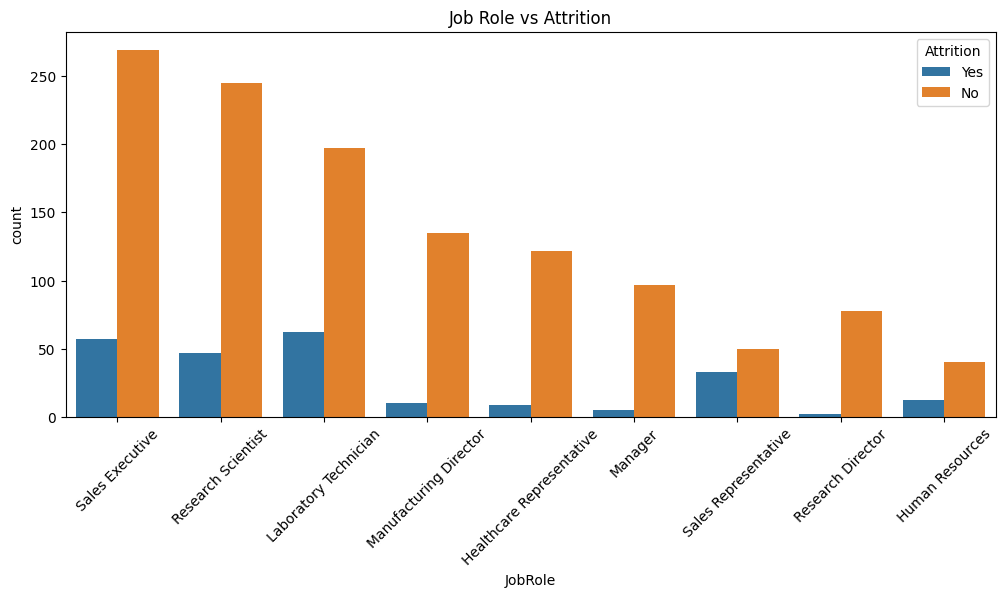

In [9]:
plt.figure(figsize=(12,5))
sns.countplot(x="JobRole", hue="Attrition", data=df)

plt.xticks(rotation=45)
plt.title("Job Role vs Attrition")
plt.savefig("images/jobrole_vs_attrition.png")

plt.show()

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Convert Attrition to numeric
le = LabelEncoder()
df["Attrition"] = le.fit_transform(df["Attrition"])

# Convert categorical columns
df_encoded = pd.get_dummies(df, drop_first=True)

# Features and Target
X = df_encoded.drop("Attrition", axis=1)
y = df_encoded["Attrition"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (1176, 47)
Testing Data: (294, 47)


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, lr_pred))

print("\nClassification Report:")
print(classification_report(y_test, lr_pred))

=== Logistic Regression ===
Accuracy: 0.8673469387755102

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.98      0.93       255
           1       0.50      0.13      0.20        39

    accuracy                           0.87       294
   macro avg       0.69      0.55      0.57       294
weighted avg       0.83      0.87      0.83       294



c:\Users\Thomas\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("=== Random Forest ===")
print("Accuracy:", accuracy_score(y_test, rf_pred))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

=== Random Forest ===
Accuracy: 0.8775510204081632

Classification Report:
              precision    recall  f1-score   support

           0       0.88      1.00      0.93       255
           1       0.80      0.10      0.18        39

    accuracy                           0.88       294
   macro avg       0.84      0.55      0.56       294
weighted avg       0.87      0.88      0.83       294



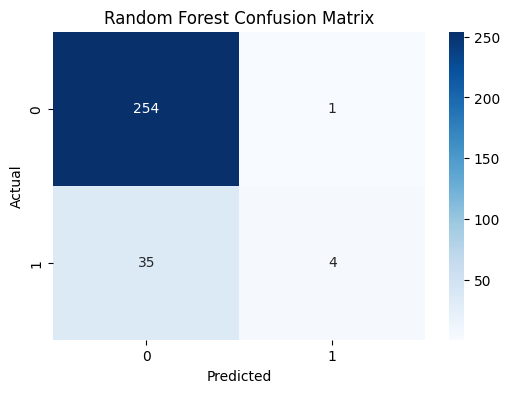

In [13]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("images/random_forest_confusion_matrix.png")

plt.show()

In [14]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

xgb_model = XGBClassifier(
    eval_metric="logloss",
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

print("=== XGBoost ===")
print("Accuracy:", accuracy_score(y_test, xgb_pred))

print("\nClassification Report:")
print(classification_report(y_test, xgb_pred))

=== XGBoost ===
Accuracy: 0.8775510204081632

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.96      0.93       255
           1       0.57      0.31      0.40        39

    accuracy                           0.88       294
   macro avg       0.74      0.64      0.67       294
weighted avg       0.86      0.88      0.86       294



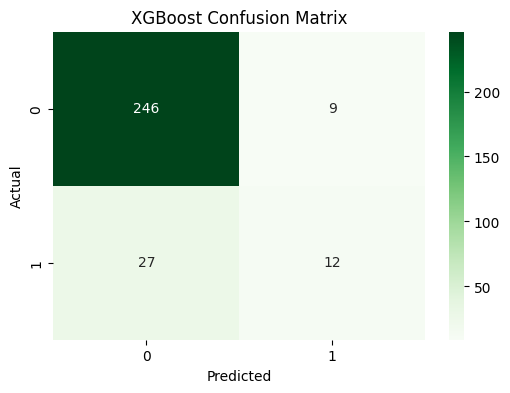

In [15]:
cm = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("images/xgboost_confusion_matrix.png")

plt.show()

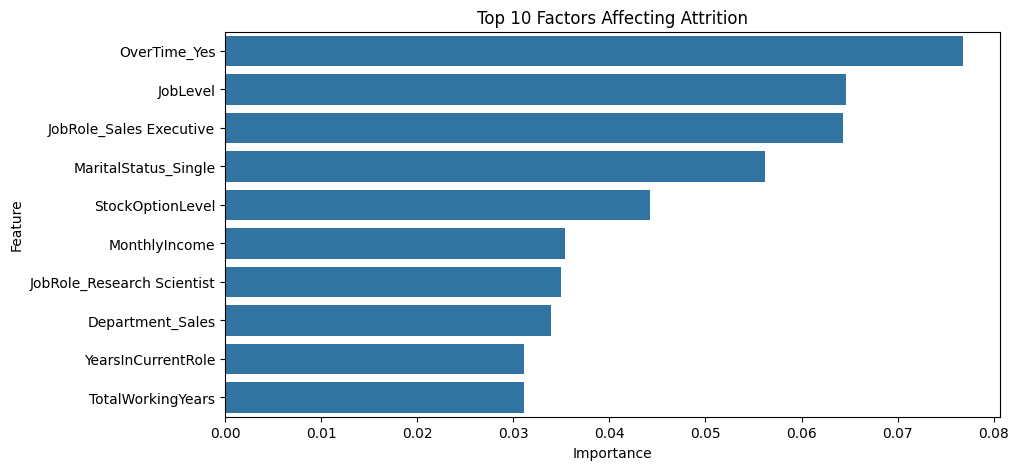

In [16]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

top10 = feature_importance.head(10)

plt.figure(figsize=(10,5))
sns.barplot(
    x="Importance",
    y="Feature",
    data=top10
)

plt.title("Top 10 Factors Affecting Attrition")

plt.savefig("images/top_factors_affecting_attrition.png")

plt.show()

In [17]:
total_employees = len(df)

employees_left = len(df[df["Attrition"] == 1])

attrition_rate = (employees_left / total_employees) * 100

average_income = df["MonthlyIncome"].mean()

print("Total Employees:", total_employees)
print("Employees Left:", employees_left)
print("Attrition Rate:", round(attrition_rate, 2), "%")
print("Average Monthly Income:", round(average_income, 2))

Total Employees: 1470
Employees Left: 237
Attrition Rate: 16.12 %
Average Monthly Income: 6502.93


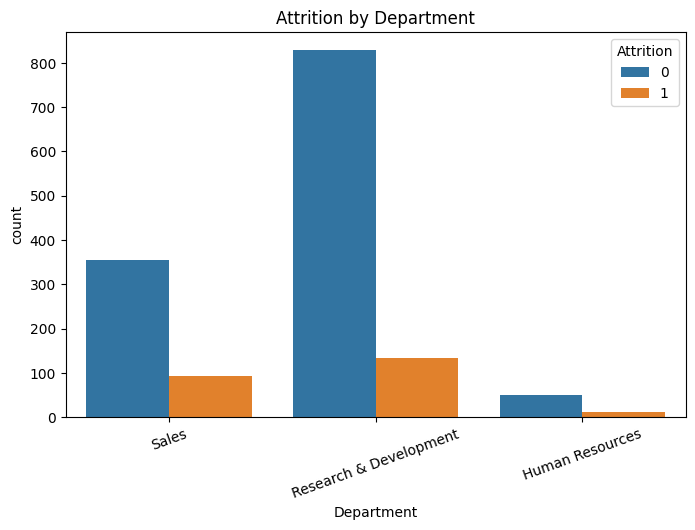

In [18]:
plt.figure(figsize=(8,5))
sns.countplot(x="Department", hue="Attrition", data=df)

plt.title("Attrition by Department")
plt.xticks(rotation=20)

plt.savefig("images/dashboard_department.png")

plt.show()

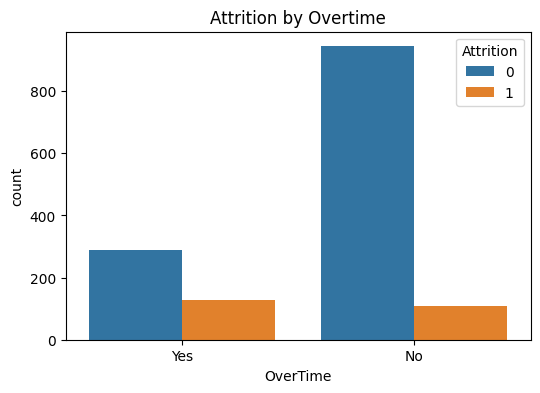

In [19]:
plt.figure(figsize=(6,4))
sns.countplot(x="OverTime", hue="Attrition", data=df)

plt.title("Attrition by Overtime")

plt.savefig("images/dashboard_overtime.png")

plt.show()

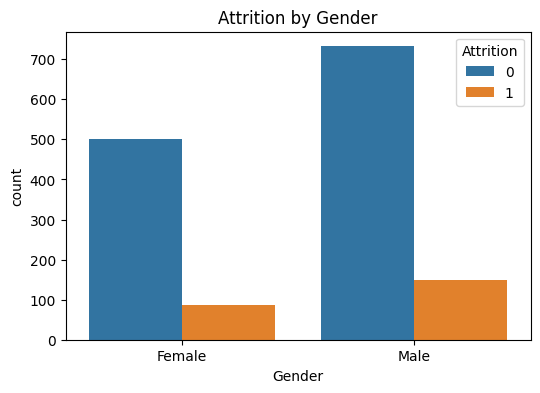

In [20]:
plt.figure(figsize=(6,4))
sns.countplot(x="Gender", hue="Attrition", data=df)

plt.title("Attrition by Gender")

plt.savefig("images/dashboard_gender.png")

plt.show()

In [22]:
from sklearn.metrics import recall_score, roc_auc_score

print("===== MODEL COMPARISON =====")

print("\nLogistic Regression")
print("Accuracy:", accuracy_score(y_test, lr_pred))
print("Recall:", recall_score(y_test, lr_pred))
print("ROC-AUC:", roc_auc_score(y_test, lr_pred))

print("\nRandom Forest")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf_pred))

print("\nXGBoost")
print("Accuracy:", accuracy_score(y_test, xgb_pred))
print("Recall:", recall_score(y_test, xgb_pred))
print("ROC-AUC:", roc_auc_score(y_test, xgb_pred))

===== MODEL COMPARISON =====

Logistic Regression
Accuracy: 0.8673469387755102
Recall: 0.1282051282051282
ROC-AUC: 0.5542986425339366

Random Forest
Accuracy: 0.8775510204081632
Recall: 0.10256410256410256
ROC-AUC: 0.5493212669683258

XGBoost
Accuracy: 0.8775510204081632
Recall: 0.3076923076923077
ROC-AUC: 0.6361990950226244


In [23]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

top10 = feature_importance.head(10)

top10

,Feature,Importance
46,OverTime_Yes,0.076814
9,JobLevel,0.064675
42,JobRole_Sales Executive,0.064294
45,MaritalStatus_Single,0.056157
18,StockOptionLevel,0.044206
11,MonthlyIncome,0.035389
41,JobRole_Research Scientist,0.034924
29,Department_Sales,0.033938
23,YearsInCurrentRole,0.031150
19,TotalWorkingYears,0.031113


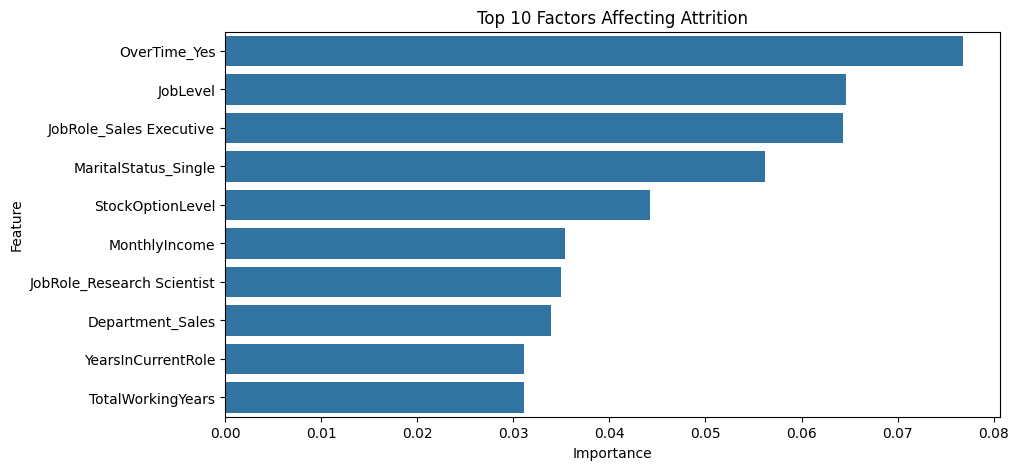

In [24]:
plt.figure(figsize=(10,5))

sns.barplot(
    x="Importance",
    y="Feature",
    data=top10
)

plt.title("Top 10 Factors Affecting Attrition")

plt.savefig("images/top_factors_affecting_attrition.png")

plt.show()